## 01. 다음 이진 검색 트리에 대해 답하시오.

**1) 이 이진 검색 트리의 리프 노드는 총 몇 개인가?**
* **정답:** 3개 (7, 17, 70)
* **풀이:** 자식 노드가 없는 노드를 리프 노드라고 합니다.

**2) 현재 높이 4를 유지하면서 키를 추가한다면 가능한 리프 노드의 최대 개수는 몇 개인가?**
* **정답:** 8개
* **풀이:** 높이가 $h$인 이진 트리에서 리프 노드의 최대 개수는 $2^{h-1}$입니다. $2^{4-1} = 2^3 = 8$입니다.

**3) 높이 4인 이진 검색 트리가 포화 이진 트리 모양이 되면 리프 노드와 내부 노드의 수는 몇 개나 차이가 나는가?**
* **정답:** 1개
* **풀이:** 
    * 전체 노드 수: $2^h - 1 = 2^4 - 1 = 15$개
    * 리프 노드 수: $2^{h-1} = 2^3 = 8$개
    * 내부 노드 수: $15 - 8 = 7$개
    * 차이: $8 - 7 = 1$개

**4) 위 3)의 성질은 높이가 $h$인 모든 포화 이진 트리에 대해 성립하는가?**
* **정답:** 예, 성립합니다.
* **풀이:** 모든 포화 이진 트리에서 리프 노드의 수 $L$과 내부 노드의 수 $I$는 항상 $L = I + 1$의 관계를 가집니다.

## 02. 임의의 완전 이진 트리에 대한 다음 물음에 답하시오.

**1) 트리의 총 노드 수가 $n$이면 리프 노드의 수는 몇 개인가?**
* **정답:** $\lceil n/2 \rceil$
* **풀이:** 완전 이진 트리에서 리프 노드는 전체 노드의 약 절반을 차지합니다.

**2) 위 1)에서 리프 노드의 수와 내부 노드의 수는 어떤 관계인가?**
* **정답:** 리프 노드의 수는 내부 노드의 수와 같거나 1만큼 더 많습니다 ($L = I$ 또는 $L = I + 1$).

## 03. 다음 이진 검색 트리에 대해 답하시오.

**1) 전위 순회 (Pre-order)**
* **방문 순서:** 5, 3, 3, 8, 7, 6, 9

**2) 중위 순회 (In-order)**
* **방문 순서:** 3, 3, 5, 6, 7, 8, 9

**3) 후위 순회 (Post-order)**
* **방문 순서:** 3, 3, 6, 7, 9, 8, 5

**4) 중위 순회는 모든 이진 검색 트리에 대해 항상 키를 정렬된 순서로 방문한다는 사실을 증명하시오.**
* **증명:** 이진 검색 트리의 정의에 따라, 모든 노드 $x$에 대해 왼쪽 서브트리의 모든 키는 $key(x)$보다 작거나 같고, 오른쪽 서브트리의 모든 키는 $key(x)$보다 큽니다. 중위 순회는 [왼쪽 서브트리 -> 루트 -> 오른쪽 서브트리] 순서로 재귀적 방문을 수행하므로, 결과적으로 가장 작은 값부터 오름차순으로 방문하게 됩니다.

## 04. 다음 이진 검색 트리에서 키 30을 검색하는 과정을 순서대로 설명하시오.

1. 루트 노드 **55**와 비교: $30 < 55$이므로 왼쪽 서브트리로 이동.
2. 노드 **15**와 비교: $30 > 15$이므로 오른쪽 서브트리로 이동.
3. 노드 **28**과 비교: $30 > 28$이므로 오른쪽 서브트리로 이동.
4. 노드 **30**과 비교: 일치하므로 검색 성공.

## 05. 키 16이 삽입된 후의 모양을 그리시오.

* **삽입 과정:** 55(L) -> 15(R) -> 28(L) -> 18(L) -> **16**
* **결과:** 18번 노드의 왼쪽 자식 노드로 16이 추가됩니다.

## 06 ~ 08. 노드 삭제 (Deletion)

**06) 키 38 삭제**
* **풀이:** 38은 자식 노드가 하나(33)인 노드입니다. 38을 삭제하고 부모 노드인 48의 왼쪽 자식으로 33을 직접 연결합니다.

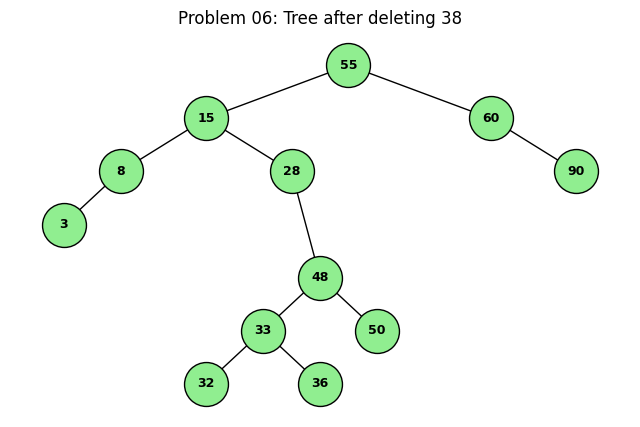

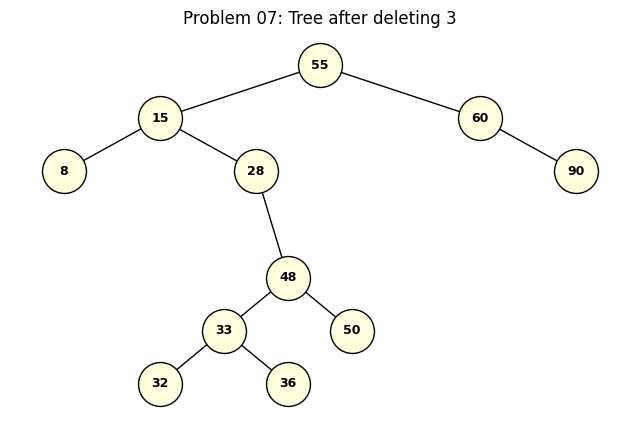

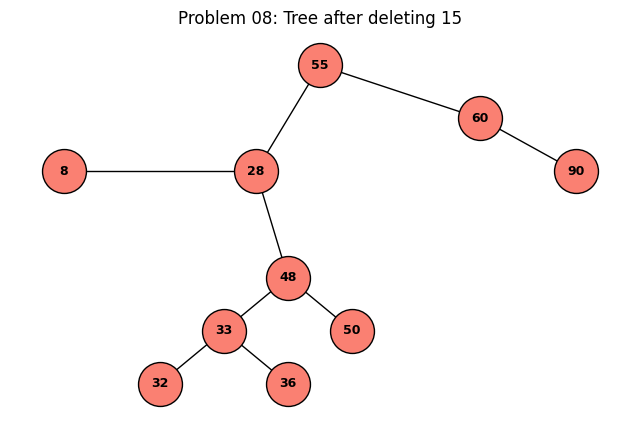

In [3]:
import sys
import subprocess

# 그림 그리기 함수 (6~8번 문제용)
import matplotlib.pyplot as plt
import networkx as nx

def draw_bst_step(edges, title, node_color='lightblue'):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    # 과제 트리에 맞춘 좌표 (페이지 2, 3의 트리 구조 참고) [cite: 22, 48]
    pos = {55:(0,10), 15:(-5,8), 60:(5,8), 8:(-8,6), 28:(-2,6), 90:(8,6), 
           3:(-10,4), 18:(-4,4), 30:(0,4), 48:(-1,2), 33:(-3,0), 50:(1,0), 
           32:(-5,-2), 36:(-1,-2)}
    
    plt.figure(figsize=(8, 5))
    plt.title(title, fontsize=12)
    nx.draw(G, pos, with_labels=True, node_size=1000, node_color=node_color, 
            edgecolors='black', font_size=9, font_weight='bold', arrows=False)
    plt.show()

# 06번: 키 38 삭제 [cite: 48, 55]
edges_06 = [(55,15), (55,60), (15,8), (15,28), (60,90), (8,3), (28,48), (48,33), (48,50), (33,32), (33,36)]
draw_bst_step(edges_06, "Problem 06: Tree after deleting 38", 'lightgreen')

# 07번: 키 3 삭제 [cite: 62]
edges_07 = [(55,15), (55,60), (15,8), (15,28), (60,90), (28,48), (48,33), (48,50), (33,32), (33,36)]
draw_bst_step(edges_07, "Problem 07: Tree after deleting 3", 'lightyellow')

# 08번: 키 15 삭제 [cite: 63]
# 15를 삭제하고 Successor인 28이 루트의 왼쪽 자식으로 올라옴
edges_08 = [(55,28), (55,60), (28,8), (28,48), (60,90), (48,33), (48,50), (33,32), (33,36)]
draw_bst_step(edges_08, "Problem 08: Tree after deleting 15", 'salmon')

**07) 키 3 삭제**
* **풀이:** 3은 리프 노드이므로 단순히 트리에서 제거합니다.

**08) 키 15 삭제**
* **풀이:** 15는 자식이 두 개인 노드입니다. 오른쪽 서브트리에서 가장 작은 노드(In-order Successor)인 18을 15의 위치로 옮기거나, 왼쪽 서브트리에서 가장 큰 노드인 8을 옮깁니다.
* (보통 Successor인 18을 사용합니다.)

## 09. $n$개의 원소로 구성되는 이진 검색 트리의 가능한 최대 높이와 최소 높이는 어떻게 되는가?

* **최대 높이:** $n$ (편향 트리 형태일 때)
* **최소 높이:** $\lfloor \log_2 n \rfloor + 1$ (완전 이진 트리 형태일 때)